# 04 - Volatility calibration

Calibration de volatilite implicite Black-Scholes et construction d'une surface implicite interpolée.

## Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.calibration import (
    ImpliedVolSurface,
    calibrate_implied_vol_panel,
    clean_option_panel,
)
from src.config import ProjectConfig
from src.market.loaders import load_option_quotes

## Load and clean option panel

In [2]:
cfg = ProjectConfig.default()
option_quotes = load_option_quotes(cfg.raw_options_path)

clean_panel = clean_option_panel(option_quotes)

pd.Series(
    {
        "raw_rows": len(option_quotes),
        "clean_rows": len(clean_panel),
        "retention_ratio": len(clean_panel) / max(len(option_quotes), 1),
        "underlyings": clean_panel["underlying"].nunique() if "underlying" in clean_panel.columns else np.nan,
    },
    name="panel_stats",
)

raw_rows           10456.000000
clean_rows          6704.000000
retention_ratio        0.641163
underlyings           10.000000
Name: panel_stats, dtype: float64

In [3]:
clean_panel[[
    "underlying",
    "option_type",
    "time_to_maturity_years",
    "strike",
    "underlying_price",
    "market_price",
    "log_moneyness",
]].head()

,underlying,option_type,time_to_maturity_years,strike,underlying_price,market_price,log_moneyness
0,AAPL,call,0.049281,90.0,264.72,175.2,-1.078863
1,AAPL,call,0.049281,95.0,264.72,170.125,-1.024796
2,AAPL,call,0.049281,100.0,264.72,165.025,-0.973502
3,AAPL,call,0.049281,105.0,264.72,160.325,-0.924712
4,AAPL,call,0.049281,110.0,264.72,155.325,-0.878192


## IV inversion and calibration diagnostics

In [4]:
calibrated, calibration_result = calibrate_implied_vol_panel(
    clean_panel,
    rate=0.02,
    dividend_yield=0.0,
)

calibration_metrics = pd.Series(
    {
        "quotes_used": len(calibrated),
        "rmse_price": calibration_result.objective_value,
        "median_iv": calibration_result.parameters.get("median_implied_vol", np.nan),
        "max_abs_error": calibration_result.parameters.get("max_abs_error", np.nan),
    },
    name="calibration_metrics",
)
calibration_metrics

quotes_used      6.338000e+03
rmse_price       1.005818e-10
median_iv        4.908718e-01
max_abs_error    1.403407e-09
Name: calibration_metrics, dtype: float64

In [5]:
calibrated[[
    "option_type",
    "time_to_maturity_years",
    "strike",
    "market_price",
    "implied_vol",
    "calibration_error",
]].head()

,option_type,time_to_maturity_years,strike,market_price,implied_vol,calibration_error
0,call,0.049281,95.0,170.125,2.064364,0.0
1,call,0.049281,100.0,165.025,1.864743,-0.0
2,call,0.049281,105.0,160.325,2.007525,-0.0
3,call,0.049281,110.0,155.325,1.911372,-0.0
4,call,0.049281,115.0,150.25,1.775485,-0.0


## Smiles by maturity bucket

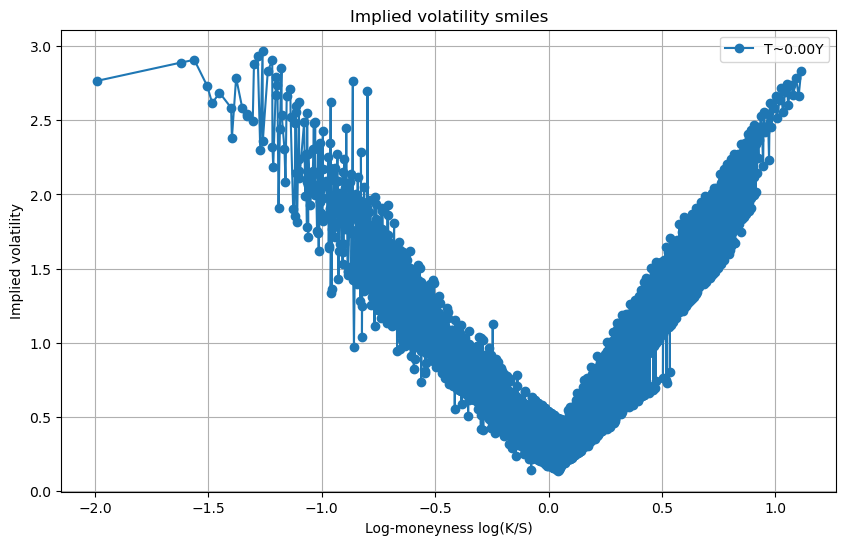

In [6]:
plot_data = calibrated.copy()
plot_data["maturity_bucket"] = (plot_data["time_to_maturity_years"] * 4.0).round() / 4.0

top_buckets = (
    plot_data["maturity_bucket"]
    .value_counts()
    .sort_values(ascending=False)
    .head(4)
    .index
)

plt.figure(figsize=(10, 6))
for bucket in top_buckets:
    smile = plot_data[plot_data["maturity_bucket"] == bucket].sort_values("log_moneyness")
    if len(smile) < 3:
        continue
    plt.plot(smile["log_moneyness"], smile["implied_vol"], marker="o", label=f"T~{bucket:.2f}Y")

plt.xlabel("Log-moneyness log(K/S)")
plt.ylabel("Implied volatility")
plt.title("Implied volatility smiles")
plt.grid(True)
plt.legend()
plt.show()

## Surface interpolation

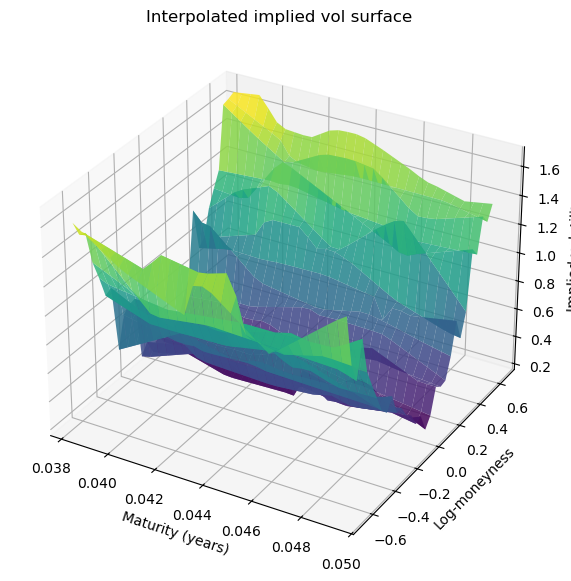

In [7]:
surface = ImpliedVolSurface.from_quotes(calibrated)

maturity_grid = np.linspace(
    calibrated["time_to_maturity_years"].quantile(0.05),
    calibrated["time_to_maturity_years"].quantile(0.95),
    30,
)
moneyness_grid = np.linspace(
    calibrated["log_moneyness"].quantile(0.05),
    calibrated["log_moneyness"].quantile(0.95),
    30,
)

tt, kk = np.meshgrid(maturity_grid, moneyness_grid, indexing="ij")
surface_values = surface.evaluate(tt, kk)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(tt, kk, surface_values, cmap="viridis", alpha=0.85)
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Log-moneyness")
ax.set_zlabel("Implied volatility")
ax.set_title("Interpolated implied vol surface")
plt.show()

## Calibration errors

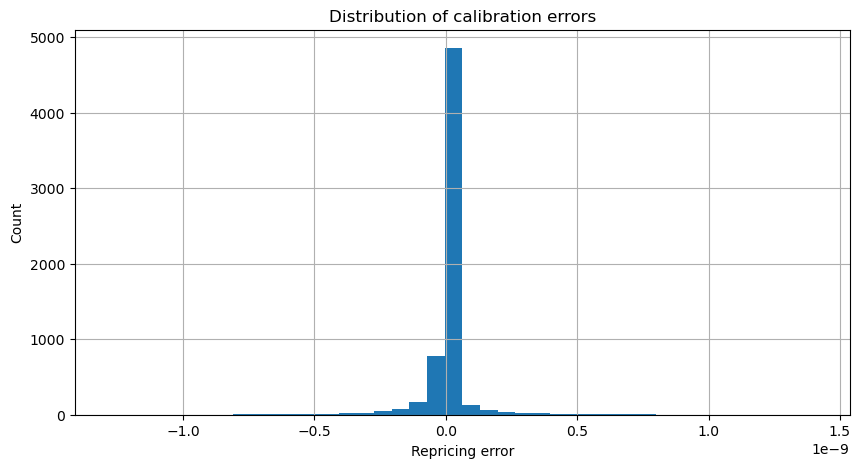

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(calibrated["calibration_error"], bins=40)
plt.xlabel("Repricing error")
plt.ylabel("Count")
plt.title("Distribution of calibration errors")
plt.grid(True)
plt.show()